This plot generates information for figure 5(b)

Mounted at /content/drive


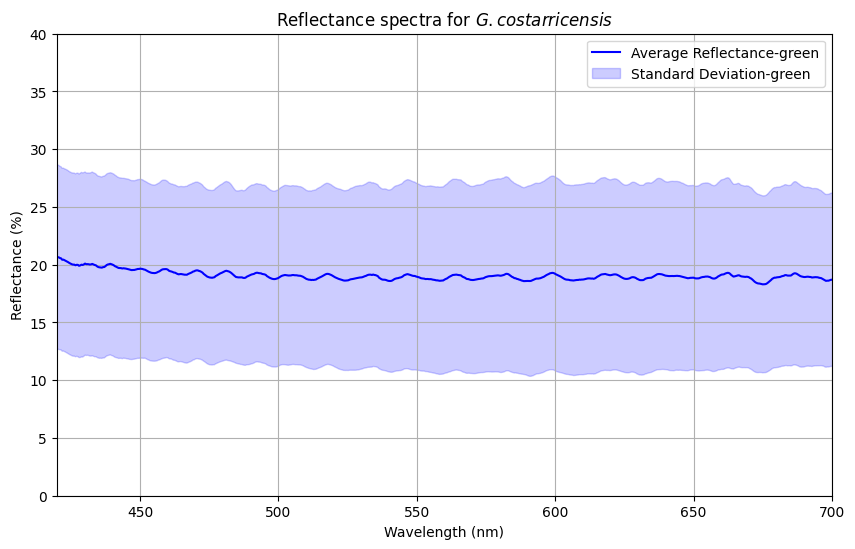

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import os # Added os module
import re # Added re module for regular expressions

# Mount Google Drive
# Change accordingly
drive.mount('/content/drive', force_remount=True)

# Path for the folder that contains the spectra
# Change accordingly
folder_path = "/content/drive/My Drive/Trabajo/Proyectos-investigacion/Paula/19112025"

# Helper function to filter filenames based on the specified pattern
def filter_spectrum_filename(filename):
    # Pattern to match 'GC-Ax-y.csv'. (Using 'T' based on observed files)
    #Change as necessary
    # Group 1: x, Group 2: y, Group 3: z
    match = re.match(r'GC-T-A(\d)(\d)-(\d+)\.csv', filename, re.IGNORECASE)
    if match:
        x_val = int(match.group(1))
        y_val = int(match.group(2))
        z_val = int(match.group(3))

        # Check conditions: x=1, y=1, z <= 5
        #if x_val <=11  and y_val <= 5:
        if x_val == 1 and y_val <= 5 and z_val < 5:
            return True
    return False

plt.figure(figsize=(10, 6))

# List all the files in the folder &
# Select those with 'gc'  in the name  and match the new pattern
all_files = os.listdir(folder_path)
csv_files = [f for f in all_files if f.lower().endswith('.csv') and filter_spectrum_filename(f)]

if not csv_files:
    print("No files found matching the specified criteria for calculating average and standard deviation.")
else:
    # List to store individual dataframes, each with 'wavelength' as index and 'reflectance' as column
    list_of_dfs = []

    for csv_file in csv_files:
        file_path = os.path.join(folder_path, csv_file)
        # Read the CSV directly from the folder
        # Use comma as delimiter and skip the first 9 metadata rows (to start reading on line 10)
        df_temp = pd.read_csv(file_path, sep=',', skiprows=9)

        # Ensure column names are consistent for merging/concatenation
        # Assume the first column is wavelength and the second is reflectance
        df_temp.columns = ['wavelength', f'reflectance_{csv_file.replace(".csv", "")}']
        list_of_dfs.append(df_temp.set_index('wavelength')) # Set wavelength as index for easier merging

    # Merge all dataframes on their wavelength index using an 'outer' join
    # This handles cases where wavelengths might not be perfectly identical across all files
    combined_df = pd.concat(list_of_dfs, axis=1, join='outer')

    # Calculate the mean and standard deviation of reflectances across files for each wavelength
    # .mean(axis=1) and .std(axis=1) operate row-wise (i.e., for each wavelength)
    mean_reflectance = combined_df.mean(axis=1)
    std_reflectance = combined_df.std(axis=1)

    # Plot the average reflectance
    plt.plot(mean_reflectance.index, mean_reflectance.values, label='Average Reflectance-green', color='blue')

    # Plot the uncertainty band (mean +/- std)
    plt.fill_between(mean_reflectance.index,
                     mean_reflectance.values - std_reflectance.values,
                     mean_reflectance.values + std_reflectance.values,
                     color='blue', alpha=0.2, label='Standard Deviation-green')

    # Set vertical axis limits
    plt.ylim(top=40) # Reverted to original notebook value
    plt.ylim(bottom=0)
    plt.xlim(left=420)
    plt.xlim(right=700)
    # Graph labels
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Reflectance (%)")
    plt.title("Reflectance spectra for $\t{G. costarricensis}$ ")
    plt.legend()
    plt.grid(True)

    plt.show()

Select files that belong to the dark surface

In [2]:
import re
import os

def filter_spectrum_filename(filename):
    # Pattern to match 'DS-Ax-y.csv'.
    # Group 1: x, Group 2: y
    match = re.match(r'GC-T-A(\d)(\d)-(\d+)\.csv', filename, re.IGNORECASE)
    if match:
        x_val = int(match.group(1))
        z_val = int(match.group(3))

        # Check condition: x <= 9
        if x_val == 1 and int(match.group(2)) == 2 or int(match.group(2))==5:
            return x_val, int(match.group(2)), z_val
    return None

# Initialize lists for grouped files
csv_files_z_le_5 = []
#csv_files_z_gt_5 = []

# List all files in the folder (assuming folder_path is already defined from previous cells)
# all_files = os.listdir(folder_path) # This line is already present in the previous cell's context

# Iterate through all files and categorize them
for filename in all_files:
    if filename.lower().endswith('.csv'):
        result = filter_spectrum_filename(filename)
        if result is not None:
            x_val, y_val, z_val = result
            file_path = os.path.join(folder_path, filename)
            if z_val <= 5:
                csv_files_z_le_5.append(file_path)
           # else:
           #     if z_val > 5:
           #        csv_files_z_gt_5.append(file_path)

print(f"Files with z <= 5: {len(csv_files_z_le_5)} files")
#print(f"Files with z > 5: {len(csv_files_z_gt_5)} files")


Files with z <= 5: 10 files


Calculation of averages and standard deviation

In [ ]:
import pandas as pd
import os

def process_spectrum_group(file_list, folder_path):
    if not file_list:
        print("No files provided for processing.")
        return None, None

    list_of_dfs = []

    for file_path in file_list:
        # Read the CSV directly from the folder
        # Use comma as delimiter and skip the first 9 metadata rows
        df_temp = pd.read_csv(file_path, sep=',', skiprows=9)

        # Ensure column names are consistent
        # Assume the first column is wavelength and the second is reflectance
        filename = os.path.basename(file_path)
        df_temp.columns = ['wavelength', f'reflectance_{filename.replace(".csv", "")}']
        list_of_dfs.append(df_temp.set_index('wavelength')) # Set wavelength as index

    # Merge all dataframes on their wavelength index
    combined_df = pd.concat(list_of_dfs, axis=1, join='outer')

    # Calculate the mean and standard deviation of reflectances
    mean_reflectance = combined_df.mean(axis=1)
    std_reflectance = combined_df.std(axis=1)

    return mean_reflectance, std_reflectance

# Process the first group (z <= 5) GENERAL SURFACE
mean_reflectance_le_5, std_reflectance_le_5 = process_spectrum_group(csv_files_z_le_5, folder_path)

# Process the second group (z > 5) GENERAL SURFACE
#mean_reflectance_gt_5, std_reflectance_gt_5 = process_spectrum_group(csv_files_z_gt_5, folder_path)

print("Processing complete for z<=5 groups. Mean and Std Dev calculated.")

Processing complete for z<=5 groups. Mean and Std Dev calculated.


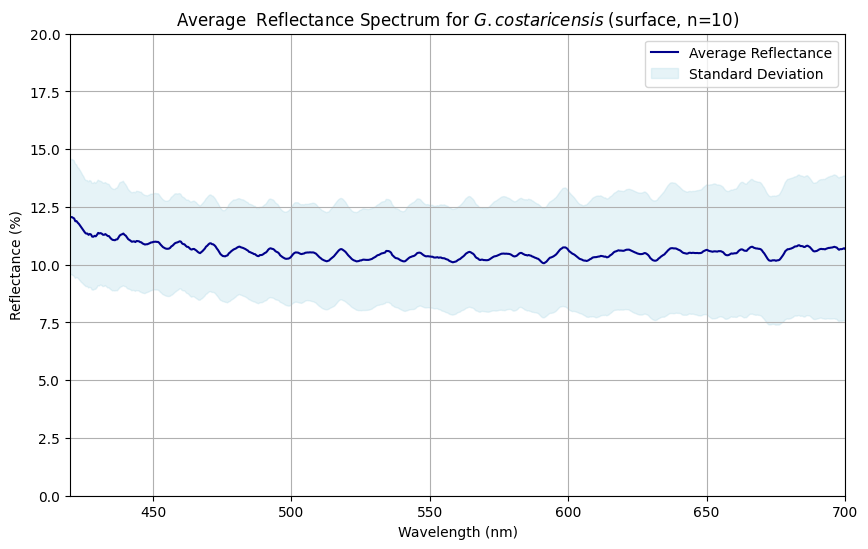

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot for y <= 5 group GENERAL SURFACE
if mean_reflectance_le_5 is not None and std_reflectance_le_5 is not None:
    plt.plot(mean_reflectance_le_5.index, mean_reflectance_le_5.values, label='Average Reflectance', color='darkblue')
    plt.fill_between(mean_reflectance_le_5.index,
                     mean_reflectance_le_5.values - std_reflectance_le_5.values,
                     mean_reflectance_le_5.values + std_reflectance_le_5.values,
                     color='lightblue', alpha=0.3, label='Standard Deviation')

# Set plot limits and labels
plt.ylim(0, 20) # Reflectance from 0-100%
plt.xlim(420, 700) # Wavelength range 420-700 nm
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance (%)")
plt.title("Average  Reflectance Spectrum for $G. costaricensis$ (surface, n=10)")
plt.legend()
plt.grid(True)

plt.show()

Select files for the strial puncture

In [ ]:
##gt 5
import re
import os

def filter_spectrum_filename(filename):
    # Pattern to match 'DS-Ax-y.csv'.
    # Group 1: x, Group 2: y
    match = re.match(r'GC-T-A(\d)(\d)-(\d+)\.csv', filename, re.IGNORECASE)
    if match:
        x_val = int(match.group(1))
        z_val = int(match.group(3))

        # Check condition: x <= 9
        if x_val == 1 and int(match.group(2)) == 3 or int(match.group(2))==4:
            return x_val, int(match.group(2)), z_val
    return None

# Initialize lists for grouped files
#csv_files_z_le_5 = []
csv_files_z_gt_5 = []

# List all files in the folder (assuming folder_path is already defined from previous cells)
# all_files = os.listdir(folder_path) # This line is already present in the previous cell's context

# Iterate through all files and categorize them
for filename in all_files:
    if filename.lower().endswith('.csv'):
        result = filter_spectrum_filename(filename)
        if result is not None:
            x_val, y_val, z_val = result
            file_path = os.path.join(folder_path, filename)
            if z_val > 5:
                csv_files_z_gt_5.append(file_path)
           # else:
           #     if z_val > 5:
           #        csv_files_z_gt_5.append(file_path)

#print(f"Files with z <= 5: {len(csv_files_z_le_5)} files")
print(f"Files with z > 5: {len(csv_files_z_gt_5)} files")
mean_reflectance_gt_5, std_reflectance_gt_5 = process_spectrum_group(csv_files_z_gt_5, folder_path)

print("Processing complete for z>5 groups. Mean and Std Dev calculated.")



Files with z > 5: 10 files
Processing complete for z>5 groups. Mean and Std Dev calculated.


In [ ]:
##gt 5
import re
import os

def filter_spectrum_filename(filename):
    # Pattern to match 'DS-Ax-y.csv'.
    # Group 1: x, Group 2: y
    match = re.match(r'GC-T-A(\d)(\d)-(\d+)\.csv', filename, re.IGNORECASE)
    if match:
        x_val = int(match.group(1))
        z_val = int(match.group(3))

        # Check condition: x <= 9
        if x_val == 1 and int(match.group(2)) == 3 or int(match.group(2))==4:
            return x_val, int(match.group(2)), z_val
    return None

# Initialize lists for grouped files
#csv_files_z_le_5 = []
csv_files_z_gt_5 = []

# List all files in the folder (assuming folder_path is already defined from previous cells)
# all_files = os.listdir(folder_path) # This line is already present in the previous cell's context

# Iterate through all files and categorize them
for filename in all_files:
    if filename.lower().endswith('.csv'):
        result = filter_spectrum_filename(filename)
        if result is not None:
            x_val, y_val, z_val = result
            file_path = os.path.join(folder_path, filename)
            if z_val > 5:
                csv_files_z_gt_5.append(file_path)
           # else:
           #     if z_val > 5:
           #        csv_files_z_gt_5.append(file_path)

#print(f"Files with z <= 5: {len(csv_files_z_le_5)} files")
print(f"Files with z > 5: {len(csv_files_z_gt_5)} files")
mean_reflectance_gt_5, std_reflectance_gt_5 = process_spectrum_group(csv_files_z_gt_5, folder_path)

print("Processing complete for z>5 groups. Mean and Std Dev calculated.")



Files with z > 5: 10 files
Processing complete for z>5 groups. Mean and Std Dev calculated.


Calculating average and mean deviation

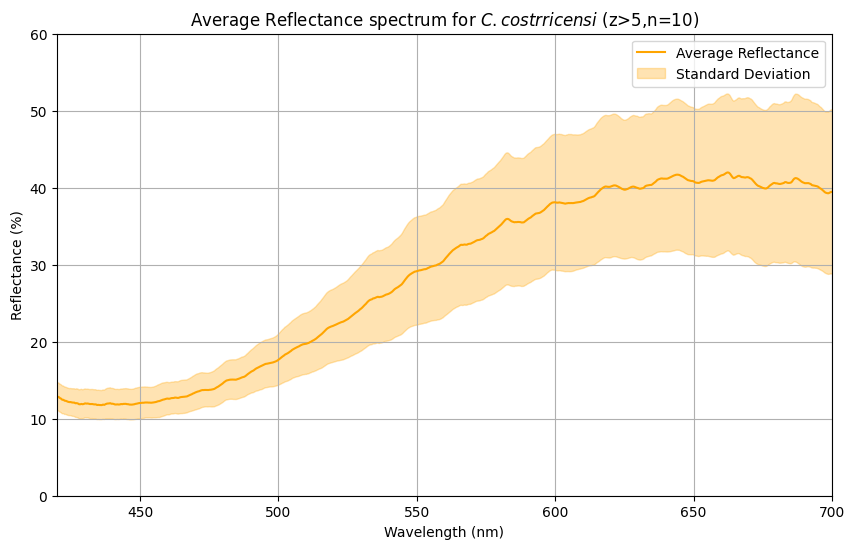

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot for y > 5 group STRIAL PUNCTURE
if mean_reflectance_gt_5 is not None and std_reflectance_gt_5 is not None:
    plt.plot(mean_reflectance_gt_5.index, mean_reflectance_gt_5.values, label='Average Reflectance', color='orange')
    plt.fill_between(mean_reflectance_gt_5.index,
                     mean_reflectance_gt_5.values - std_reflectance_gt_5.values,
                     mean_reflectance_gt_5.values + std_reflectance_gt_5.values,
                     color='orange', alpha=0.3, label='Standard Deviation ')

# Set plot limits and labels
plt.ylim(0, 60) # Reflectance from 0-100%
plt.xlim(420, 700) # Wavelength range 420-700 nm
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance (%)")
plt.title("Average Reflectance spectrum for $C. costrricensi$ (z>5,n=10)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
import os

# Ensure folder_path is defined (it should be from previous cells)
# if 'folder_path' not in locals():
#    folder_path = '/content/drive/My Drive/Trabajo/Proyectos-investigacion/Paula/19112025'

# Create a DataFrame to store the mean reflectances from both groups
GC_mean_reflectances_strial = pd.DataFrame({
    'wavelength': mean_reflectance_le_5.index,
    'mean_reflectance_gt_5': mean_reflectance_gt_5.values
})
GC_mean_reflectances_dark = pd.DataFrame({
    'wavelength': mean_reflectance_le_5.index,
    'mean_reflectance_le_5': mean_reflectance_le_5.values

})
# Set wavelength as index for the combined DataFrame
GC_mean_reflectances_strial= GC_mean_reflectances_strial.set_index('wavelength')
GC_mean_reflectances_dark = GC_mean_reflectances_dark.set_index('wavelength')
# Define the output file path
output_csv_path = os.path.join(folder_path, 'GC_average_reflectance_strial.csv')

# Export the DataFrame to a CSV file
GC_mean_reflectances_strial.to_csv(output_csv_path, index=True)
output_csv_path = os.path.join(folder_path, 'GC_std_strial.csv')
std_reflectance_gt_5.to_csv(output_csv_path, index=True)

output_csv_path = os.path.join(folder_path, 'GC_average_reflectance_dark.csv')
GC_mean_reflectances_dark.to_csv(output_csv_path, index=True)
output_csv_path = os.path.join(folder_path, 'GC_std_dark.csv')
std_reflectance_le_5.to_csv(output_csv_path, index=True)

print(f"Combined average reflectances exported to: {output_csv_path}")

Combined average reflectances exported to: /content/drive/My Drive/Trabajo/Proyectos-investigacion/Paula/19112025/GC_std_dark.csv


In [ ]:
import pandas as pd
import os

# Ensure folder_path is defined (it should be from previous cells)
# if 'folder_path' not in locals():
#    folder_path = '/content/drive/My Drive/Trabajo/Proyectos-investigacion/Paula/19112025'

# Create a DataFrame to store the mean reflectances from both groups
GC_mean_reflectances_strial = pd.DataFrame({
    'wavelength': mean_reflectance_le_5.index,
    'mean_reflectance_gt_5': mean_reflectance_gt_5.values
})
GC_mean_reflectances_dark = pd.DataFrame({
    'wavelength': mean_reflectance_le_5.index,
    'mean_reflectance_le_5': mean_reflectance_le_5.values

})
# Set wavelength as index for the combined DataFrame
GC_mean_reflectances_strial= GC_mean_reflectances_strial.set_index('wavelength')
GC_mean_reflectances_dark = GC_mean_reflectances_dark.set_index('wavelength')
# Define the output file path
output_csv_path = os.path.join(folder_path, 'GC_average_reflectance_strial.csv')

# Export the DataFrame to a CSV file
GC_mean_reflectances_strial.to_csv(output_csv_path, index=True)
output_csv_path = os.path.join(folder_path, 'GC_std_strial.csv')
std_reflectance_gt_5.to.csv(output_csv_path, index=True)

output_csv_path = os.path.join(folder_path, 'GC_average_reflectance_dark.csv')
GC_mean_reflectances_dark.to_csv(output_csv_path, index=True)

print(f"Combined average reflectances exported to: {output_csv_path}")

Combined average reflectances exported to: /content/drive/My Drive/Trabajo/Proyectos-investigacion/Paula/19112025/GC_average_reflectance_dark.csv


Detailed visualization

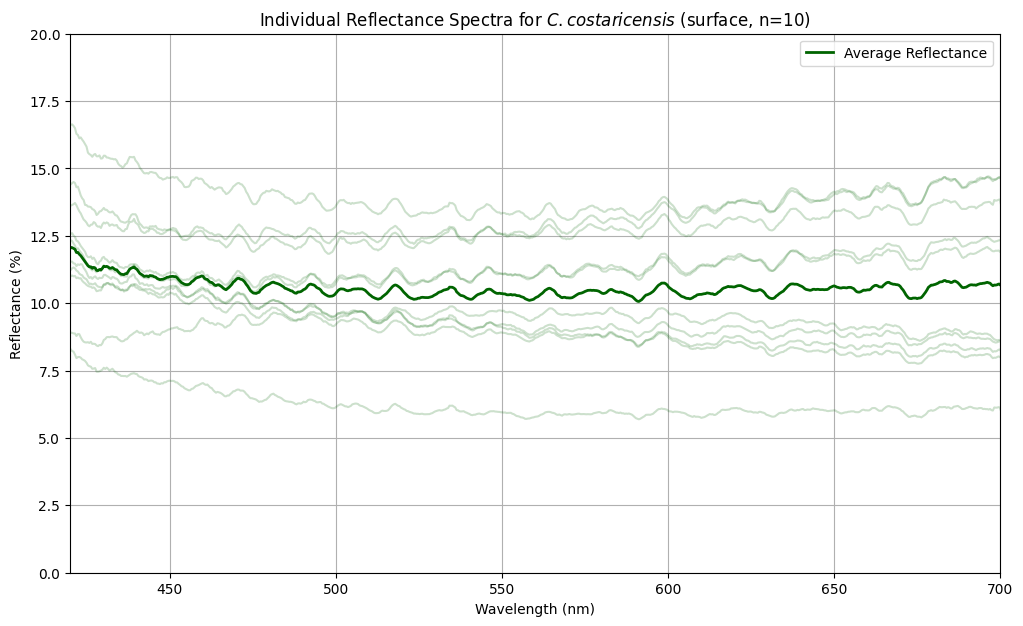

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

plt.figure(figsize=(12, 7))

if not csv_files_z_le_5:
    print("No files found for y <= 5 group to plot individual curves.")
else:
    for file_path in csv_files_z_le_5:
        try:
            df_temp = pd.read_csv(file_path, sep=',', skiprows=9)
            # Assuming the first column is wavelength and the second is reflectance
            df_temp.columns = ['wavelength', 'reflectance']
            plt.plot(df_temp['wavelength'], df_temp['reflectance'], color='darkgreen', alpha=0.2)
        except Exception as e:
            print(f"Error reading {os.path.basename(file_path)}: {e}")

# Plot the average reflectance for y <= 5 group on top for clarity
if mean_reflectance_le_5 is not None:
    plt.plot(mean_reflectance_le_5.index, mean_reflectance_le_5.values, label='Average Reflectance', color='darkgreen', linewidth=2)


# Set plot limits and labels
plt.ylim(0, 20) # Reflectance from 0-100%
plt.xlim(420, 700) # Wavelength range 420-700 nm
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance (%)")
plt.title("Individual Reflectance Spectra for $C. costaricensis$ (surface, n=10)")
plt.legend()
plt.grid(True)

plt.show()

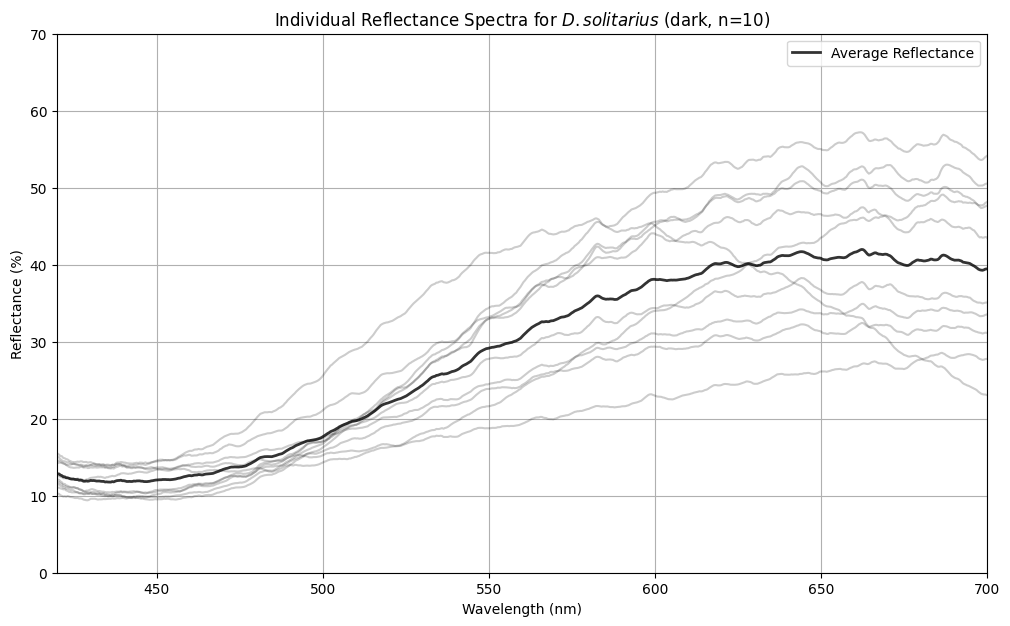

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

plt.figure(figsize=(12, 7))

if not csv_files_z_gt_5:
    print("No files found for y > 5 group to plot individual curves.")
else:
    for file_path in csv_files_z_gt_5:
        try:
            df_temp = pd.read_csv(file_path, sep=',', skiprows=9)
            # Assuming the first column is wavelength and the second is reflectance
            df_temp.columns = ['wavelength', 'reflectance']
            plt.plot(df_temp['wavelength'], df_temp['reflectance'], color='black', alpha=0.2)
        except Exception as e:
            print(f"Error reading {os.path.basename(file_path)}: {e}")

# Plot the average reflectance for y > 5 group on top for clarity
if mean_reflectance_gt_5 is not None:
    plt.plot(mean_reflectance_gt_5.index, mean_reflectance_gt_5.values, label='Average Reflectance', color='black', alpha=0.8, linewidth=2)

# Set plot limits and labels
plt.ylim(0, 70) # Reflectance from 0-100%
plt.xlim(420, 700) # Wavelength range 420-700 nm
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance (%)")
plt.title("Individual Reflectance Spectra for $D. solitarius$ (dark, n=10)")
plt.legend()
plt.grid(True)

plt.show()

Visualization of both averages together

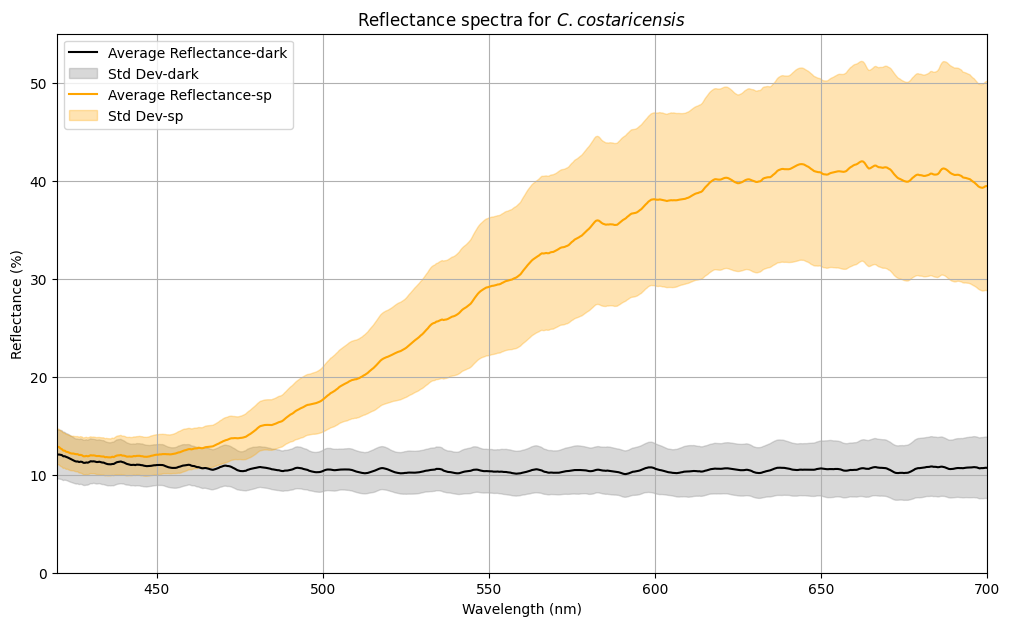

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Plot for y <= 5 group
if mean_reflectance_le_5 is not None and std_reflectance_le_5 is not None:
    plt.plot(mean_reflectance_le_5.index, mean_reflectance_le_5.values, label='Average Reflectance-dark', color='black')
    plt.fill_between(mean_reflectance_le_5.index,
                     mean_reflectance_le_5.values - std_reflectance_le_5.values,
                     mean_reflectance_le_5.values + std_reflectance_le_5.values,
                     color='gray', alpha=0.3, label='Std Dev-dark')

# Plot for y > 5 group
if mean_reflectance_gt_5 is not None and std_reflectance_gt_5 is not None:
    plt.plot(mean_reflectance_gt_5.index, mean_reflectance_gt_5.values, label='Average Reflectance-sp', color='orange')
    plt.fill_between(mean_reflectance_gt_5.index,
                     mean_reflectance_gt_5.values - std_reflectance_gt_5.values,
                     mean_reflectance_gt_5.values + std_reflectance_gt_5.values,
                     color='orange', alpha=0.3, label='Std Dev-sp')

# Set plot limits and labels
plt.ylim(0, 55) # Reflectance from 0-100%
plt.xlim(420, 700) # Wavelength range 420-700 nm
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance (%)")
plt.title("Reflectance spectra for $C. costaricensis$ ")
plt.legend()
plt.grid(True)
output_svg_path = os.path.join('/content/drive/My Drive/Trabajo/Proyectos-investigacion/Paula/', 'GC.svg')
plt.savefig(output_svg_path, format='svg')

plt.show()
